scatter plot produce
for different method, get the final converged (alpha_x, alpha_y) of the optimized solution from different running trials as a cluster of points, 

In [ ]:
import os
CURRENT_DIR = os.getcwd()

import pickle
# load the results

with open(os.path.join(CURRENT_DIR, "../results/scenario_A_results_v3.pkl"), "rb") as f:    
    data = pickle.load(f)
    df_A = data["df_A"]
    results_A = data["results_A"]
    final_summary = data["final_summary"]

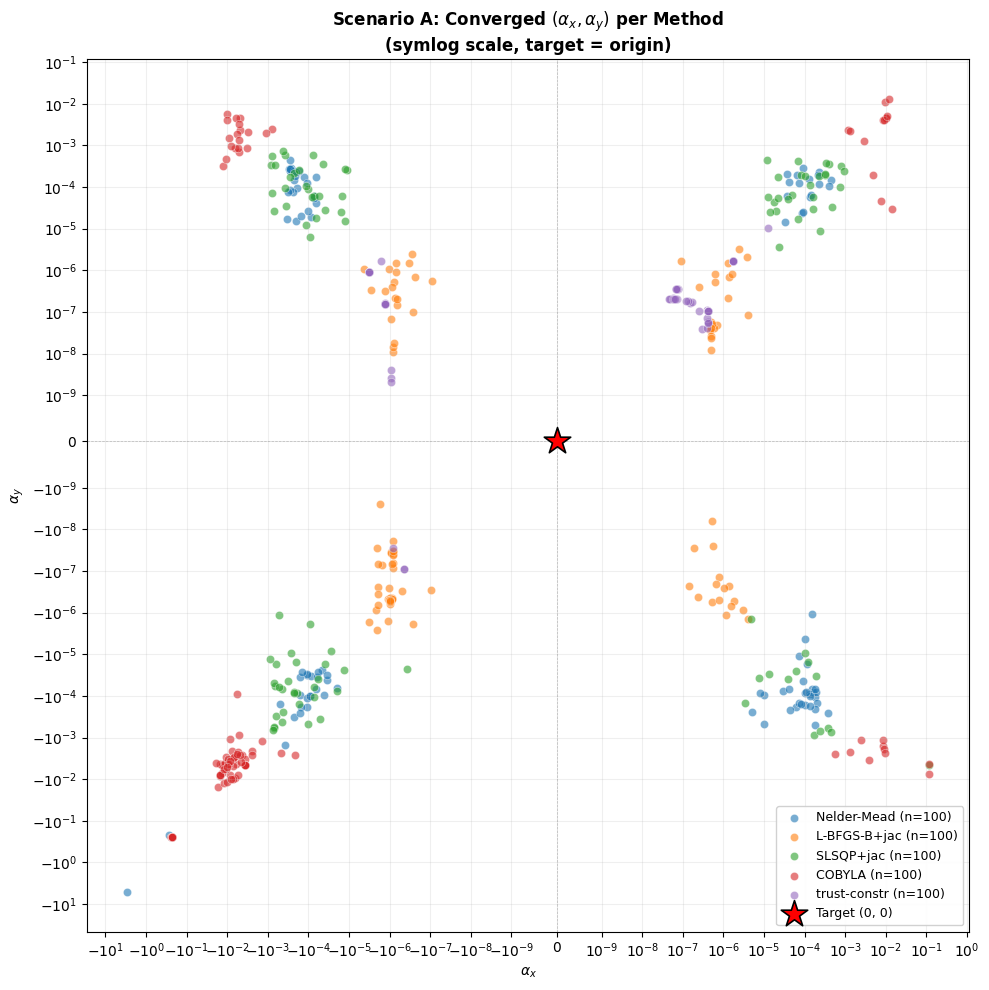

In [14]:
# 2. give the plot for the five methods
# -each method: 100 converged currents leading to 100 (alpha_x, alpha_y) pairs
import matplotlib.pyplot as plt
import numpy as np

methods = df_A['method_tag'].unique()
colors = plt.colormaps.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(10,10))

for i, m in enumerate(methods):
    sub = df_A[df_A['method_tag'] == m]
    ax.scatter(sub['alpha_x'], sub['alpha_y'],
               s=35, alpha=0.6, color=colors(i),
               edgecolors='white', linewidths=0.4,
               label=f"{m} (n={len(sub)})")

ax.scatter(0, 0, marker='*', s=400, color='red', zorder=10,
           edgecolors='black', linewidths=1.2, label='Target (0, 0)')

ax.set_xscale('symlog', linthresh=1e-9)
ax.set_yscale('symlog', linthresh=1e-9)

ax.axhline(0, color='gray', lw=0.5, ls='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, ls='--', alpha=0.5)

ax.set_xlabel(r'$\alpha_x$', fontsize=10)
ax.set_ylabel(r'$\alpha_y$', fontsize=10)
ax.set_title('Scenario A: Converged $(\\alpha_x, \\alpha_y)$ per Method\n(symlog scale, target = origin)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='best', framealpha=0.9)
ax.grid(True, which='both', alpha=0.2)

fig.tight_layout()
plt.show()

contour plot/heat map produce
firstly, get the background heat map with a scan for I_1 and I_2 in (0,1.5) A with 200 uniformly arranged points, then derive the contour plot 

after that, give 5 optimization iteration trajectories for each method, and plot them on the heat map to show the optimization process

Grid 60 60, MSE range [1.37e-03, 3.52e+03]


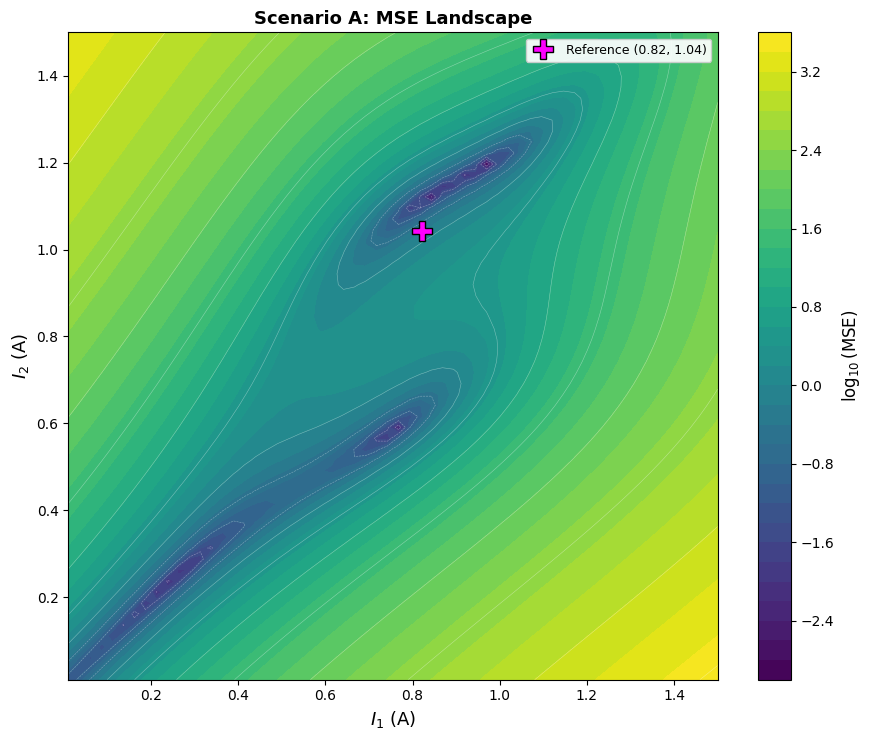

In [17]:
# MSE landscape heatmap

import pickle, os
import numpy as np
import matplotlib.pyplot as plt

with open(os.path.join(CURRENT_DIR, "../results/scenario_A_landscape.pkl"), "rb") as f:
    L = pickle.load(f)
I1_vals, I2_vals, MSE_grid = L["I1_vals"], L["I2_vals"], L["MSE_grid"]

print(f"Grid {L['N_GRID']} {L['N_GRID']}, MSE range [{np.nanmin(MSE_grid):.2e}, {np.nanmax(MSE_grid):.2e}]")

Z = np.log10(np.maximum(MSE_grid, 1e-16))

fig, ax = plt.subplots(figsize=(9, 7.5))

cf = ax.contourf(I1_vals, I2_vals, Z, levels=40, cmap='viridis')
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$\log_{10}(\mathrm{MSE})$', fontsize=12)

ax.contour(I1_vals, I2_vals, Z, levels=12, colors='white', linewidths=0.4, alpha=0.4)

ax.plot(0.8218, 1.0430, 'P', color='magenta', markersize=15,
        markeredgecolor='black', label='Reference (0.82, 1.04)', zorder=11)

traj_path = os.path.join(CURRENT_DIR, "../results/scenario_A_trajectories.pkl")

ax.set_xlabel(r'$I_1$ (A)', fontsize=13)
ax.set_ylabel(r'$I_2$ (A)', fontsize=13)
ax.set_title('Scenario A: MSE Landscape', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right', framealpha=0.92)
ax.set_xlim(I1_vals[0], I1_vals[-1])
ax.set_ylim(I2_vals[0], I2_vals[-1])
fig.tight_layout()
plt.show()

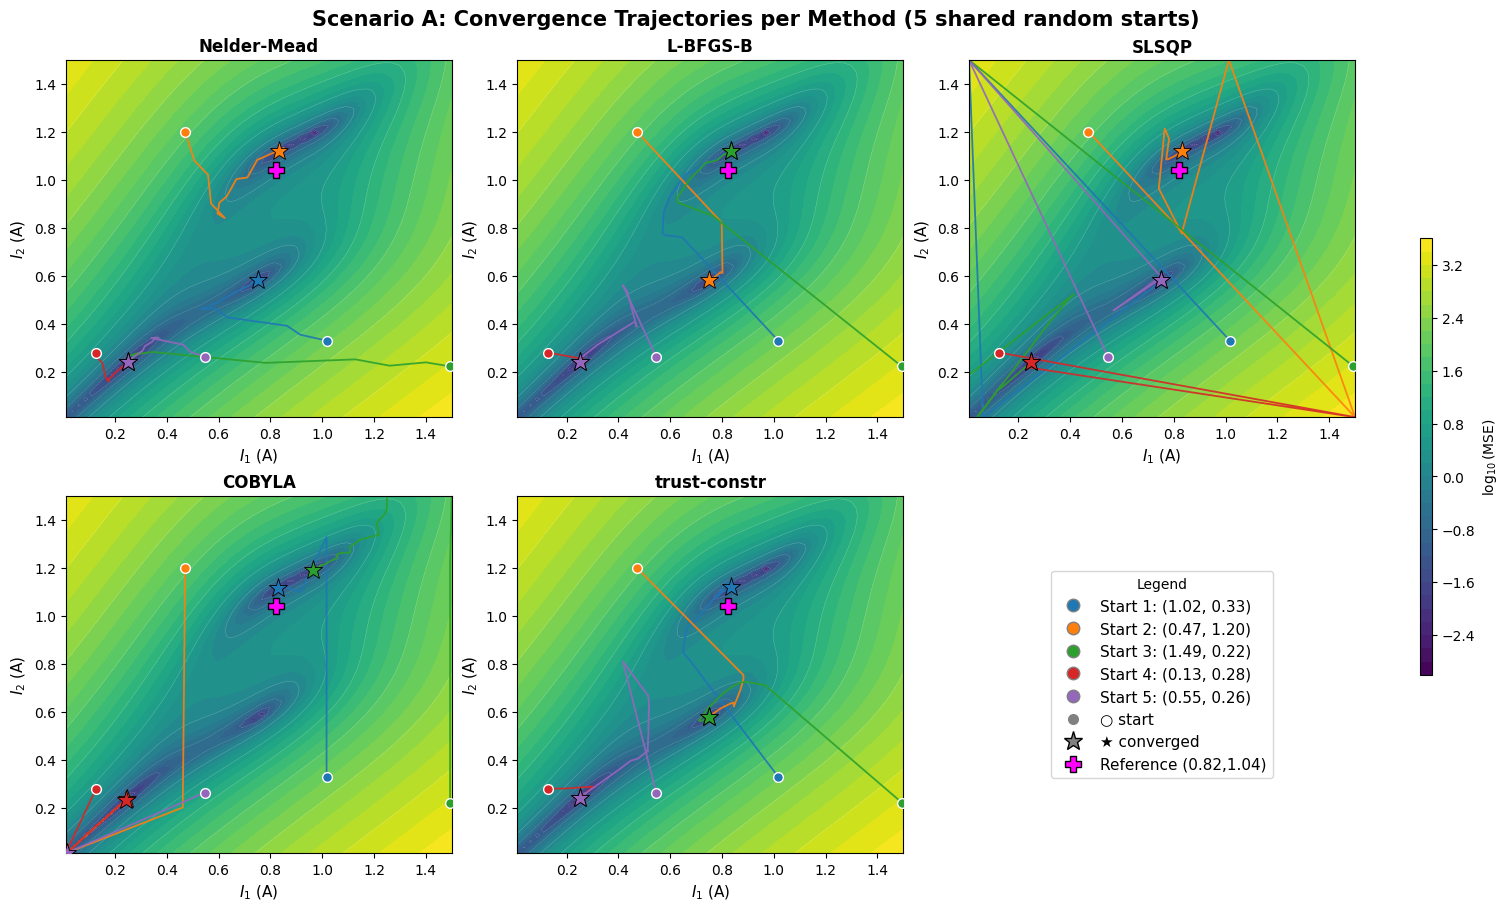

In [ ]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

with open(os.path.join(CURRENT_DIR, "../results/scenario_A_landscape.pkl"), "rb") as f:
    L = pickle.load(f)
with open(os.path.join(CURRENT_DIR, "../results/scenario_A_trajectories.pkl"), "rb") as f:
    T = pickle.load(f)

I1_vals, I2_vals, MSE_grid = L["I1_vals"], L["I2_vals"], L["MSE_grid"]
trajectories, STARTS = T["trajectories"], T["starts"]
Z = np.log10(np.maximum(MSE_grid, 1e-16))

methods = list(trajectories.keys())
start_colors = plt.colormaps.get_cmap('tab10')

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.flatten()

for idx, method in enumerate(methods):
    ax = axes[idx]
    cf = ax.contourf(I1_vals, I2_vals, Z, levels=40, cmap='viridis')
    ax.contour(I1_vals, I2_vals, Z, levels=10, colors='white', linewidths=0.3, alpha=0.3)

    for s_idx, d in enumerate(trajectories[method]):
        path = d["path"]; c = start_colors(s_idx)
        ax.plot(path[:,0], path[:,1], '-', color=c, linewidth=1.3, alpha=0.9)
        ax.plot(path[0,0],  path[0,1],  'o', color=c, ms=7,  mec='white', mew=1.0, zorder=9)   # 起点
        ax.plot(path[-1,0], path[-1,1], '*', color=c, ms=14, mec='black', mew=0.6, zorder=10)  # 终点

    ax.plot(0.8218, 1.0430, 'P', color='magenta', ms=12, mec='black', zorder=11)  # 参考解
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel(r'$I_1$ (A)', fontsize=11); ax.set_ylabel(r'$I_2$ (A)', fontsize=11)
    ax.set_xlim(I1_vals[0], I1_vals[-1]); ax.set_ylim(I2_vals[0], I2_vals[-1])

axes[5].axis('off')
leg = [Line2D([0],[0], marker='o', color='w', markerfacecolor=start_colors(i),
              markeredgecolor='gray', ms=9,
              label=f"Start {i+1}: ({STARTS[i,0]:.2f}, {STARTS[i,1]:.2f})")
       for i in range(len(STARTS))]
leg += [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray', ms=9, label='○ start'),
        Line2D([0],[0], marker='*', color='w', markerfacecolor='gray', markeredgecolor='black', ms=14, label='★ converged'),
        Line2D([0],[0], marker='P', color='w', markerfacecolor='magenta', markeredgecolor='black', ms=12, label='Reference (0.82,1.04)')]
axes[5].legend(handles=leg, loc='center', fontsize=11, frameon=True, title='Legend')

fig.colorbar(cf, ax=list(axes), label=r'$\log_{10}(\mathrm{MSE})$', shrink=0.55, aspect=35)
fig.suptitle('Scenario A: Convergence Trajectories per Method (5 shared random starts)',
             fontsize=15, fontweight='bold')
plt.show()